## Comparison of Imputation Methods Based on the "Asparate Aminotransferase (AST)_median" Column and the Pattern of Missingness

In [1]:
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pyarrow.feather as feather
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.feather as feather
import missingno as msno
from statsmodels.imputation import mice

# Define paths
ROOT_FOLDER = os.path.dirname(os.getcwd())
PROCESSED_DATA = os.path.join(ROOT_FOLDER, "data", "processed")
ICU_TAB_FEATURES = os.path.join(PROCESSED_DATA, "icu_tabular_features_0M_0ed859c799267d4ae737f8814d52726d_20240518.feather")

# Load the Feather file
df = feather.read_feather(ICU_TAB_FEATURES)

# Prepare a new DataFrame to store the original and imputed values
comparison_df = pd.DataFrame()
comparison_df['original'] = df['Asparate Aminotransferase (AST)_median']

# Impute with mean
comparison_df['mean_imputed'] = df['Asparate Aminotransferase (AST)_median'].fillna(df['Asparate Aminotransferase (AST)_median'].mean())

# Impute with KNN
knn_imputer = KNNImputer(n_neighbors=5)
comparison_df['knn_imputed'] = knn_imputer.fit_transform(df[['Asparate Aminotransferase (AST)_median']])

# Impute with MICE (Multivariate Imputation by Chained Equations)
mice_imputer = IterativeImputer(max_iter=10, random_state=0)
comparison_df['mice_imputed'] = mice_imputer.fit_transform(df[['Asparate Aminotransferase (AST)_median']])

# Forward fill
comparison_df['forward_fill'] = df['Asparate Aminotransferase (AST)_median'].ffill()

# Backward fill
comparison_df['backward_fill'] = df['Asparate Aminotransferase (AST)_median'].bfill()

# Interpolation
comparison_df['interpolation'] = df['Asparate Aminotransferase (AST)_median'].interpolate(method='linear')

# Combined Method
df['combined'] = df['Asparate Aminotransferase (AST)_median'].ffill().fillna(df['Asparate Aminotransferase (AST)_median'].mean())
comparison_df['combined_imputation'] = df['combined']

# Display the updated comparison table
comparison_df.head(20)


,original,mean_imputed,knn_imputed,mice_imputed,forward_fill,backward_fill,interpolation,combined_imputation
0,NaN,380.705357,380.705357,380.705357,NaN,30.0,NaN,380.705357
1,NaN,380.705357,380.705357,380.705357,NaN,30.0,NaN,380.705357
2,NaN,380.705357,380.705357,380.705357,NaN,30.0,NaN,380.705357
3,NaN,380.705357,380.705357,380.705357,NaN,30.0,NaN,380.705357
4,30.0,30.000000,30.000000,30.000000,30.0,30.0,30.000000,30.000000
5,219.0,219.000000,219.000000,219.000000,219.0,219.0,219.000000,219.000000
6,NaN,380.705357,380.705357,380.705357,219.0,163.5,212.833333,219.000000
7,NaN,380.705357,380.705357,380.705357,219.0,163.5,206.666667,219.000000
8,NaN,380.705357,380.705357,380.705357,219.0,163.5,200.500000,219.000000
9,NaN,380.705357,380.705357,380.705357,219.0,163.5,194.333333,219.000000


In [2]:
print(df.shape)
nan_count = df['Asparate Aminotransferase (AST)_median'].isnull().sum()
print(f"Number of Nan in Asparate Aminotransferase (AST)_median : {nan_count}")

(133, 386)
Number of Nan in Asparate Aminotransferase (AST)_median : 77


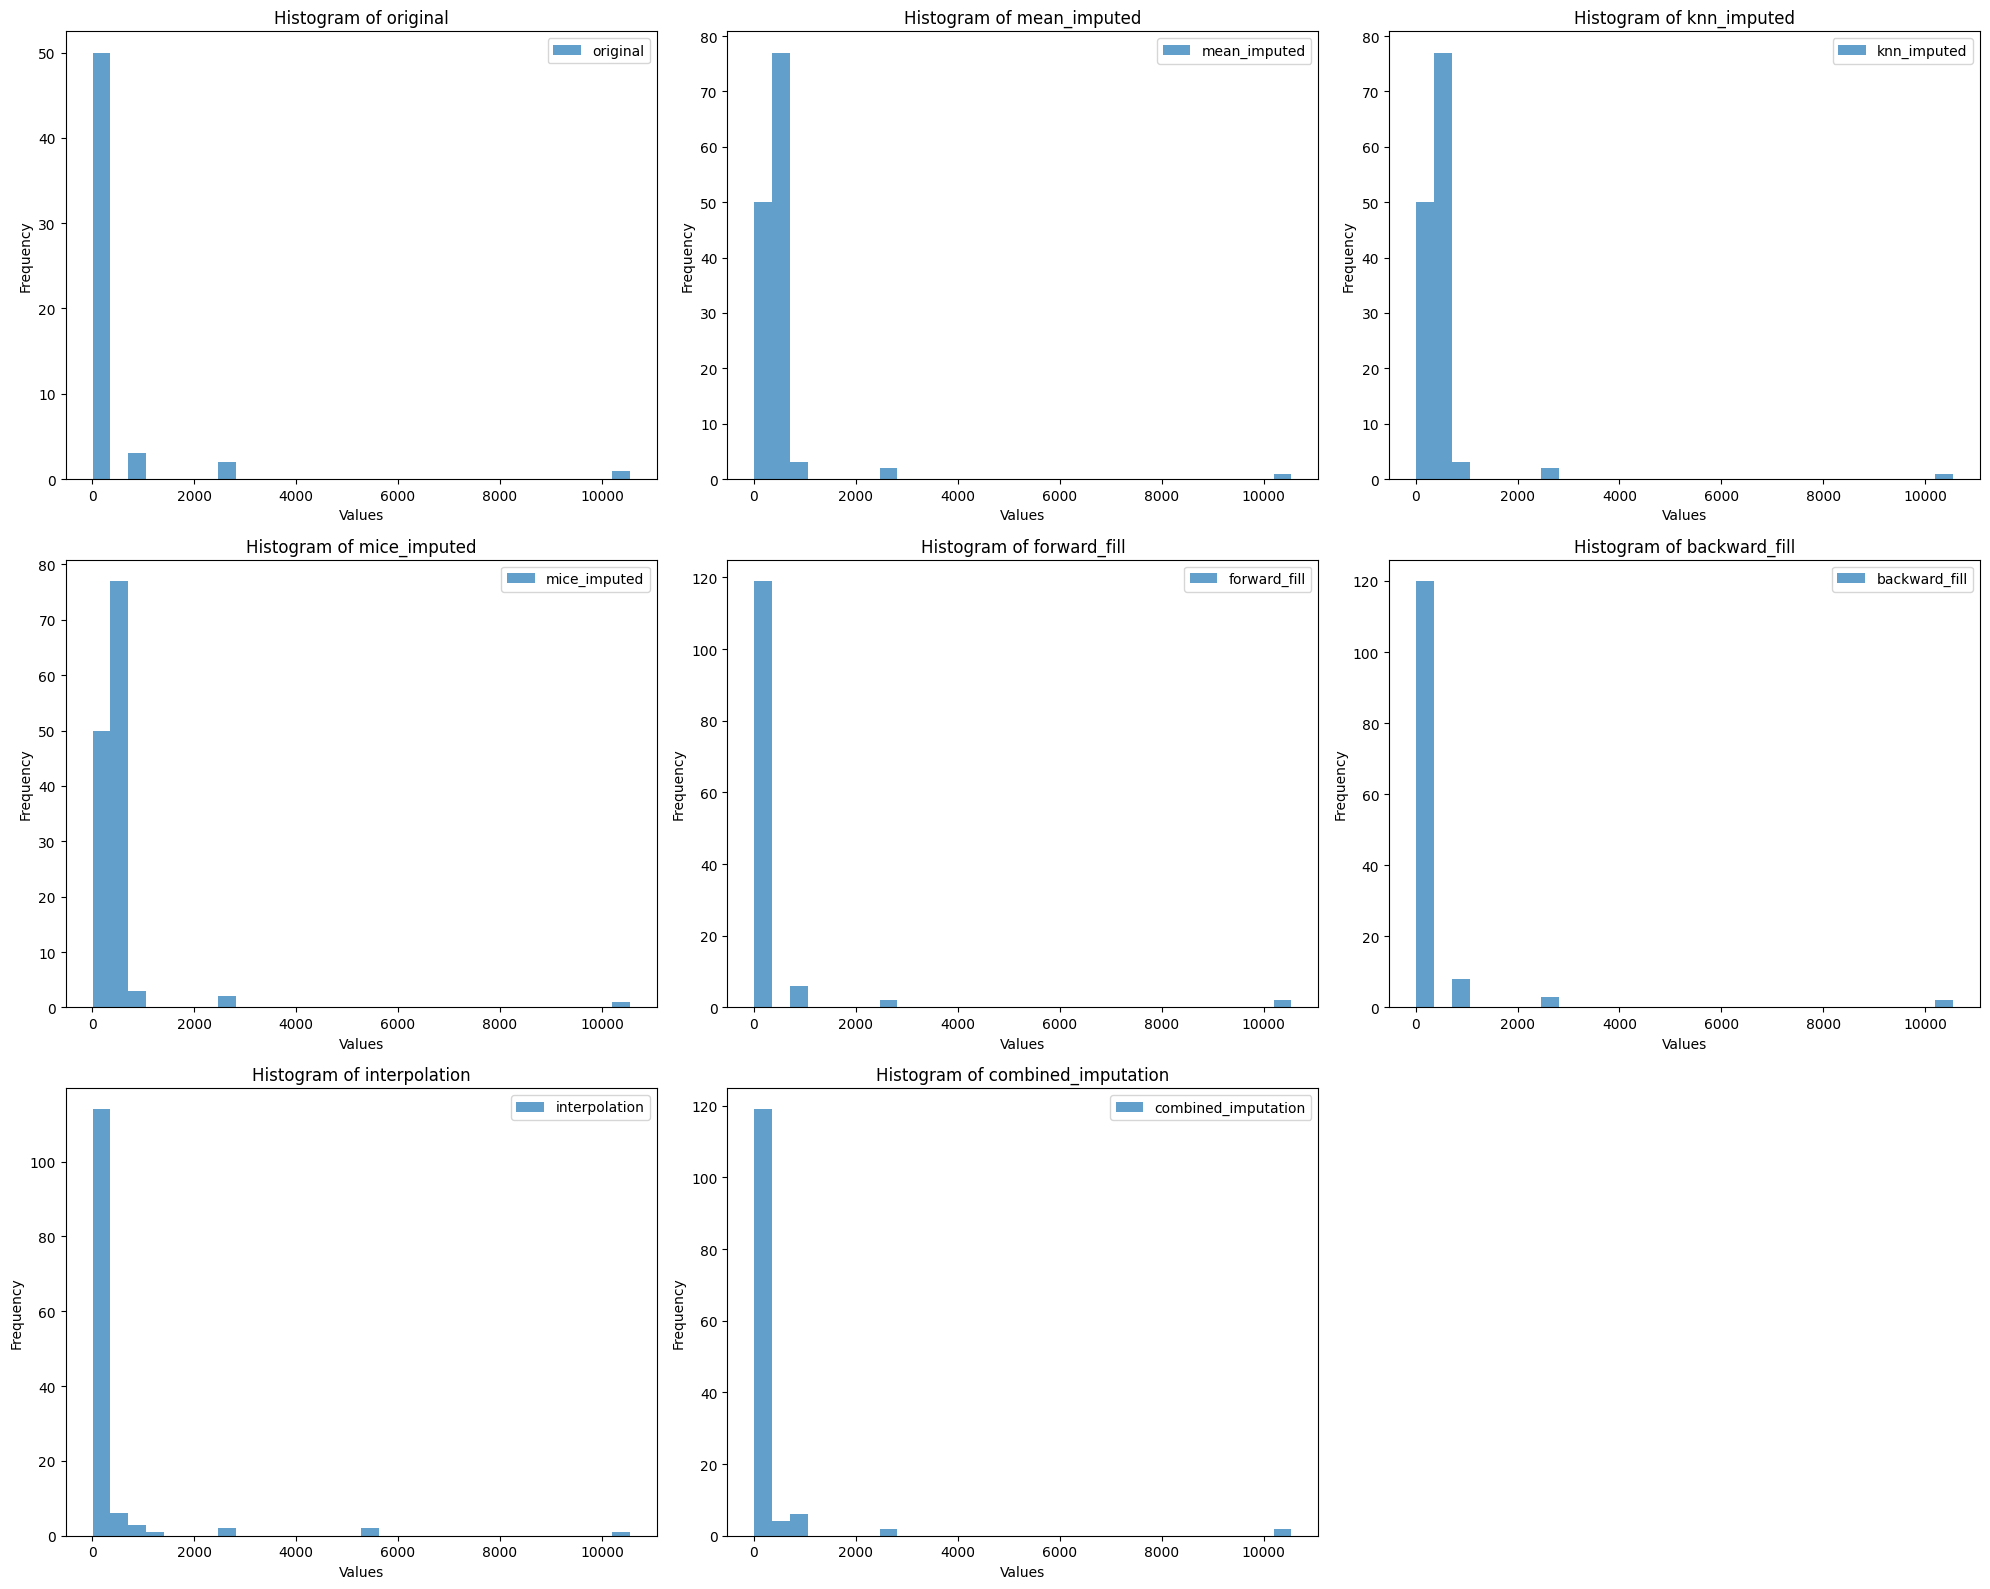

In [3]:
# Plot histograms
methods = ['original', 'mean_imputed', 'knn_imputed', 'mice_imputed', 'forward_fill', 'backward_fill', 'interpolation', 'combined_imputation']
plt.figure(figsize=(20, 16))

for i, method in enumerate(methods, 1):
    plt.subplot(3, 3, i)  # Create a subplot for each method
    plt.hist(comparison_df[method].dropna(), bins=30, alpha=0.7, label=method)
    plt.title(f'Histogram of {method}')
    plt.xlabel('Values')
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()
plt.show()

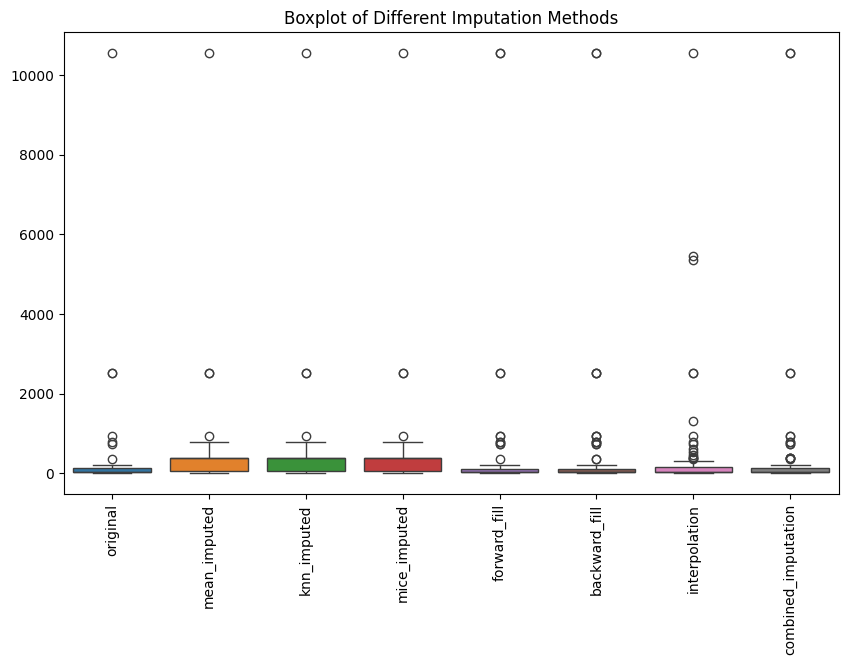

In [4]:
# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=comparison_df)
plt.xticks(rotation=90)
plt.title("Boxplot of Different Imputation Methods")
plt.show()


                                          Missing Values  Percentage
metastatic_cancer                                    133  100.000000
aids                                                 133  100.000000
neoplasie                                            133  100.000000
daily bmi                                            131   98.496241
Temperature_std                                      119   89.473684
...                                                  ...         ...
O2 Saturation Pulseoxymetry Alarm - High               0    0.000000
Non-Invasive Blood Pressure Alarm - Low                0    0.000000
Non-Invasive Blood Pressure Alarm - High               0    0.000000
NBP Alarm Source                                       0    0.000000
combined                                               0    0.000000

[386 rows x 2 columns]


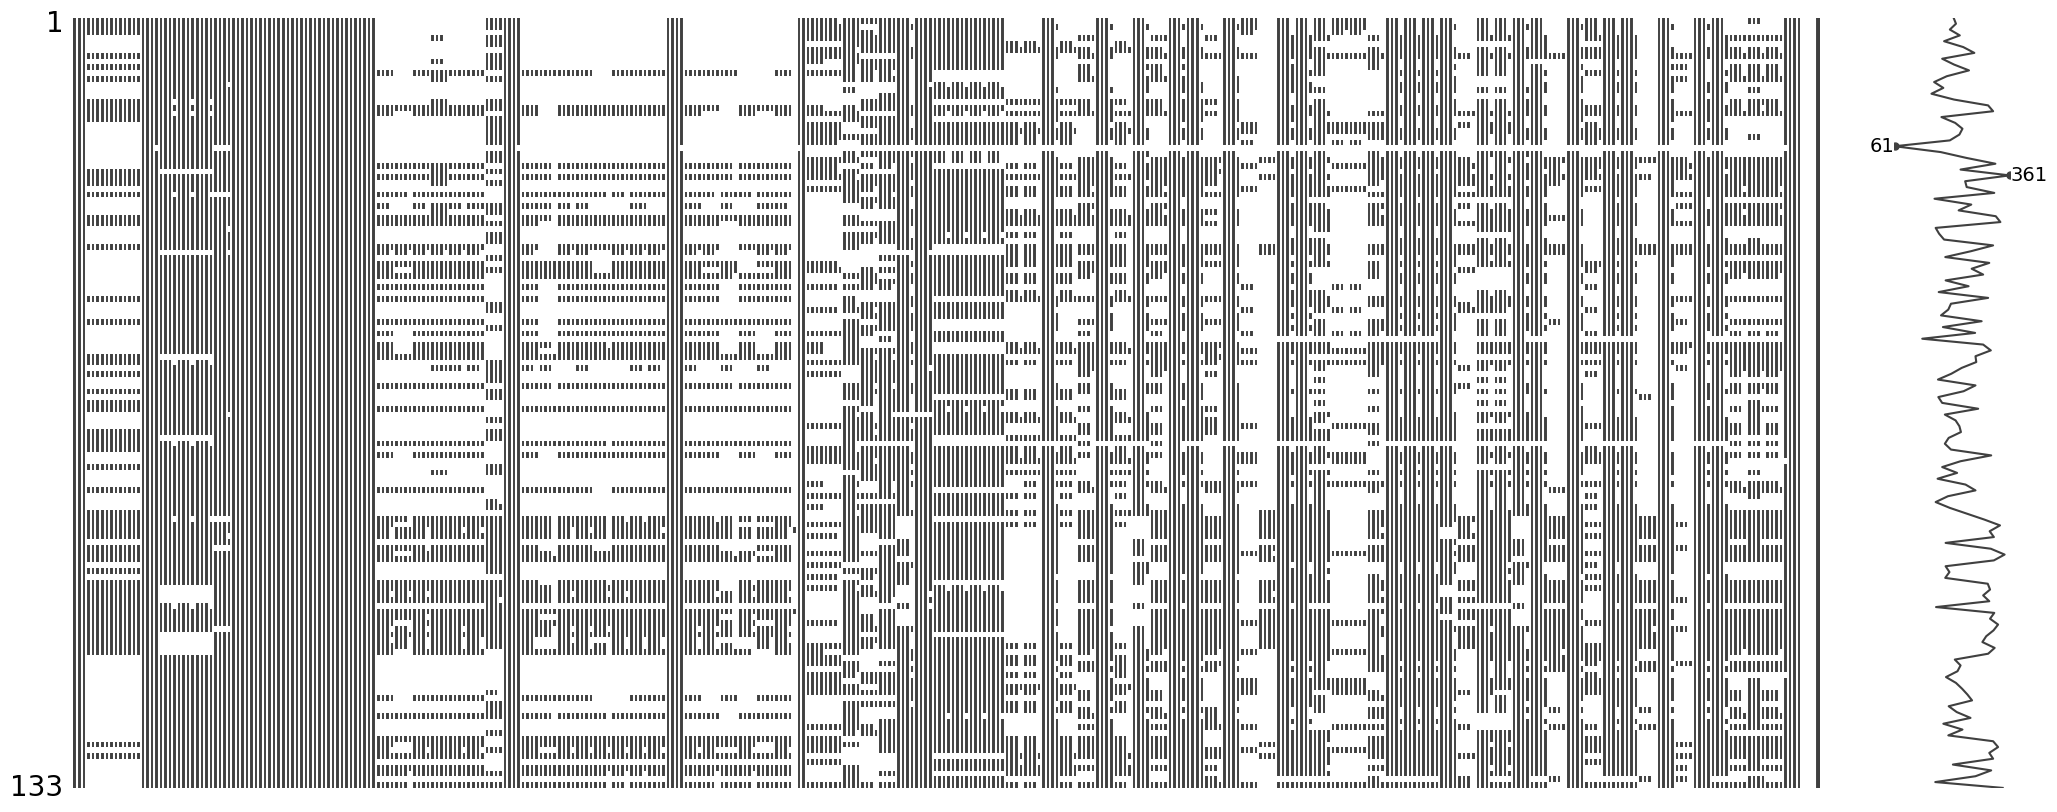

In [12]:
import pandas as pd
import pyarrow.feather as feather
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.imputation import mice

# Summarize missing data
missing_summary = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({
    'Missing Values': missing_summary,
    'Percentage': missing_percentage
})

print(missing_data.sort_values(by='Percentage', ascending=False))

# Visualize missing data pattern
msno.matrix(df)
plt.show()
